# Inscritos e primeira POC de redação — ENEM 2025

Execute com ENEM 2025 (.venv), após o notebook 01 (trusted v2). Este notebook audita a contagem independente de PARTICIPANTES e produz apenas agregados de redação. Não faz join entre bases nem recalcula notas por avaliador. Contrato: `../docs/contrato_analitico_redacao_2025.md`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/redacao.py").is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.inscritos_execucao import executar_inscritos
from src.redacao_execucao import executar_redacao
from src.redacao_graficos import gerar_graficos_redacao
print("Projeto:", raiz)


Projeto: C:\Users\SamuelCaetanoPacheco\Desktop\ENEM-Data-Analysis


## Inscritos: três referências, sem misturar universos

A contagem de PARTICIPANTES usa parser estrito Latin-1, `;`, chave e ano. O total oficial confirmado é uma referência documental datada; a limitação de acesso direto ao PDF está no relatório. Igualdade de volume não identifica registros entre bases.


In [2]:
inscritos = executar_inscritos(raiz)
display(pd.DataFrame([
    {"Universo":"Inscrições confirmadas — Inep", "Quantidade":inscritos["oficial"]["inscricoes_confirmadas"]},
    {"Universo":"Registros divulgados de PARTICIPANTES", "Quantidade":inscritos["participantes"]["registros"]},
    {"Universo":"Registros divulgados de RESULTADOS", "Quantidade":inscritos["registros_resultados"]}]))
print("Diferença oficial − PARTICIPANTES:", inscritos["diferenca_oficial_participantes"])
print("Sem causa atribuída; sem join. Fonte:", inscritos["oficial"]["url"])


,Universo,Quantidade
0,Inscrições confirmadas — Inep,4811338
1,Registros divulgados de PARTICIPANTES,4810772
2,Registros divulgados de RESULTADOS,4810772


Diferença oficial − PARTICIPANTES: 566
Sem causa atribuída; sem join. Fonte: https://download.inep.gov.br/enem/outros_documentos/enem_balanco_da_aplicacao_09_11_2025.pdf


## Nota final registrada, situação e competências

A nota final inclui todos os valores não nulos, inclusive zero e situações problemáticas. Situações usam a base total. Competências usam status=1 e nota final + cinco competências completas, preservando zeros; recorte comum explicitamente diferente da distribuição final.


In [3]:
redacao, auditoria_redacao = executar_redacao(raiz)
display(pd.DataFrame(redacao["final"]).round(2))
display(pd.DataFrame(redacao["status"]).round(2))
display(pd.DataFrame(redacao["competencias"]).round(2))
print("Controles:", auditoria_redacao["controles"])
print("Alertas:", auditoria_redacao["alertas"])
assert all(auditoria_redacao["controles"]["reconciliacoes"].values())
assert auditoria_redacao["sha256_antes"] == auditoria_redacao["sha256_depois"]


,n,zeros,media,minimo_observado,maximo_observado,q1,mediana,q3,total_base,sem_nota,pct_com_nota_base
0,3457555,211859,580.8,0.0,1000.0,480.0,600.0,720.0,4810772,1353217,71.87


,codigo,quantidade,com_nota,sem_nota,zeros,positivas,situacao,percentual_base
0,1.0,3245696,3245696,0,0,3245696,Sem problemas,67.47
1,2.0,3070,3070,0,3070,0,Anulada,0.06
2,3.0,54840,54840,0,54840,0,Cópia Texto Motivador,1.14
3,4.0,114329,114329,0,114329,0,Em Branco,2.38
4,6.0,13576,13576,0,13576,0,Fuga ao tema,0.28
5,7.0,5661,5661,0,5661,0,Não atendimento ao tipo textual,0.12
6,8.0,16975,16975,0,16975,0,Texto insuficiente,0.35
7,9.0,3408,3408,0,3408,0,Parte desconectada,0.07
8,NaN,1353217,0,1353217,0,0,Sem status registrado,28.13


,campo,competencia,n,zeros,media,minimo_observado,maximo_observado,q1,mediana,q3
0,NU_NOTA_COMP1,Domínio da escrita formal,3245696,589,120.62,0.0,200.0,100.0,120.0,140.0
1,NU_NOTA_COMP2,Tema e tipo textual,3245696,0,136.97,40.0,200.0,120.0,120.0,160.0
2,NU_NOTA_COMP3,Defesa de um ponto de vista,3245696,1072,119.63,0.0,200.0,100.0,120.0,140.0
3,NU_NOTA_COMP4,Mecanismos da argumentação,3245696,1199,127.35,0.0,200.0,100.0,120.0,160.0
4,NU_NOTA_COMP5,Proposta de intervenção,3245696,305510,114.15,0.0,200.0,80.0,120.0,160.0


Controles: {'sem_problemas': 3245696, 'incompletas_sem_problemas': 0, 'recorte_competencias': 3245696, 'soma_comparavel': 3457555, 'soma_divergente': 0, 'soma_divergente_recorte': 0, 'nota_sem_status': 0, 'status_sem_nota': 0, 'positivas_status_problematico': 0, 'final_fora_escala': 0, 'competencias_fora_escala': 0, 'nulos_campos': {'TP_STATUS_REDACAO': 1353217, 'NU_NOTA_REDACAO': 1353217, 'NU_NOTA_COMP1': 1353217, 'NU_NOTA_COMP2': 1353217, 'NU_NOTA_COMP3': 1353217, 'NU_NOTA_COMP4': 1353217, 'NU_NOTA_COMP5': 1353217}, 'reconciliacoes': {'status_total': True, 'status_notas': True, 'status_zeros': True, 'distribuicao_notas': True, 'distribuicao_zeros': True, 'competencias_denominador': True, 'competencias_exclusoes': True, 'presencas_total': True}}
Alertas: {}


## Dois gráficos para revisão

Somente agregados saem do DuckDB. O histograma mantém zeros; notas ausentes ficam fora. Médias e medianas de competências não permitem diagnosticar causas. A redação não é uma escala equivalente à TRI.


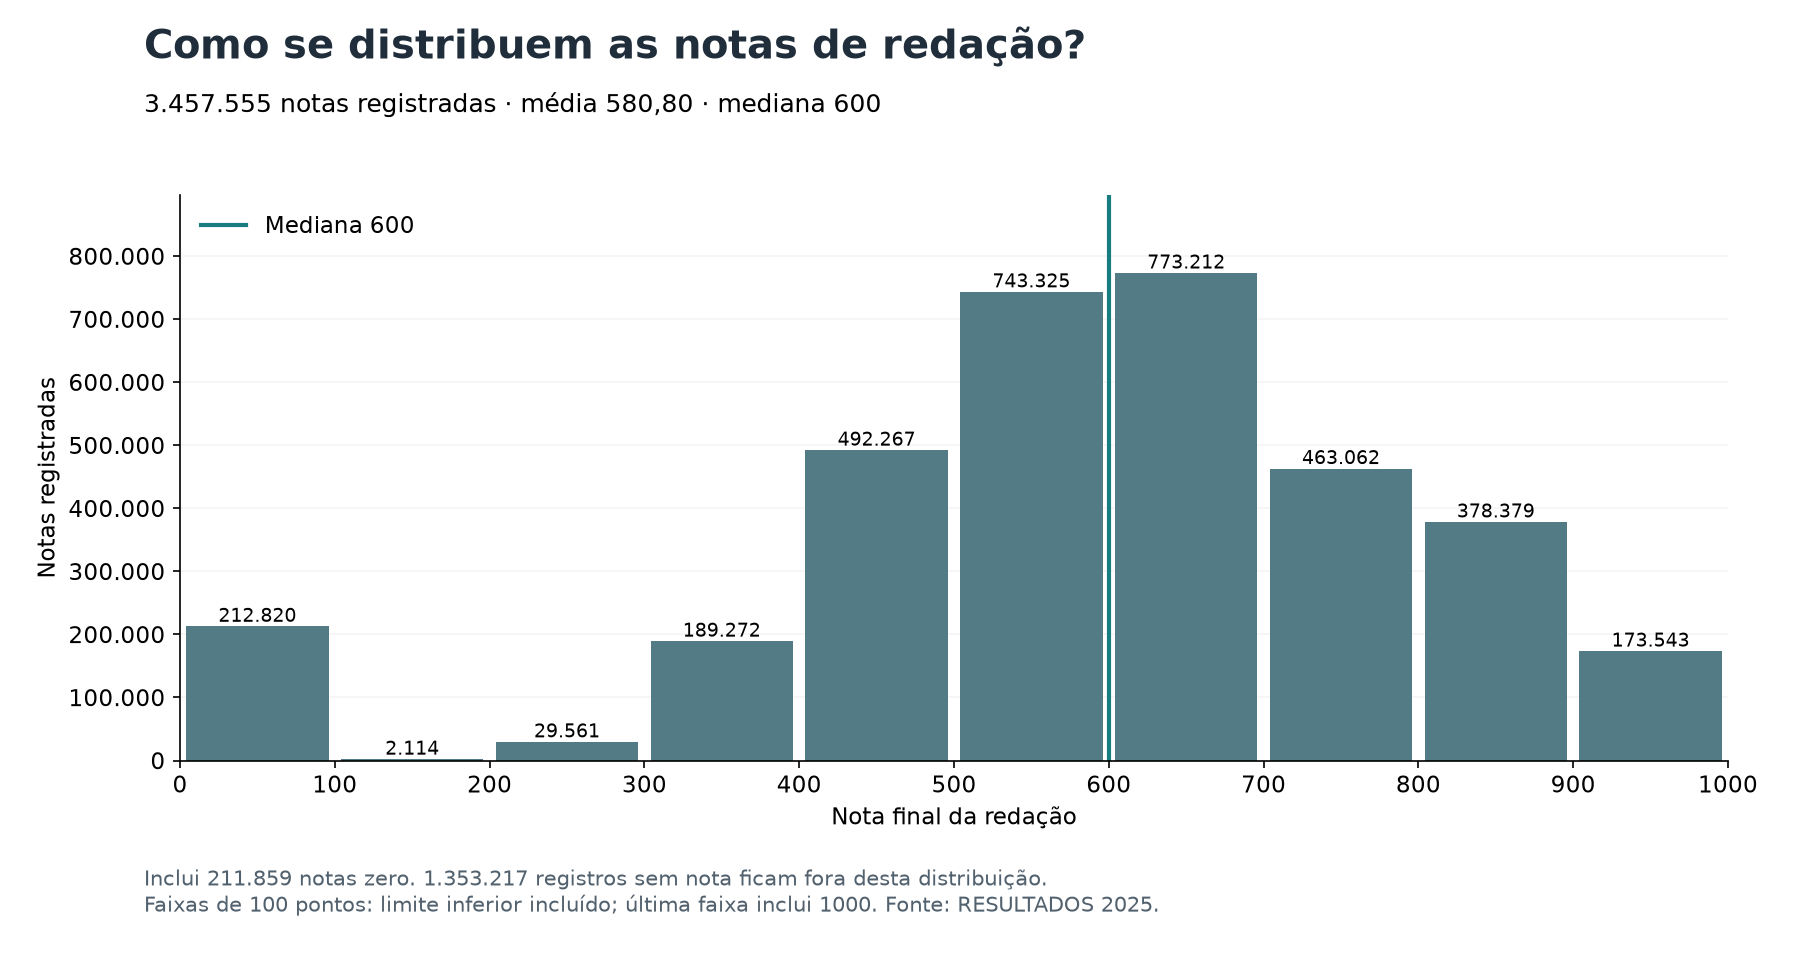

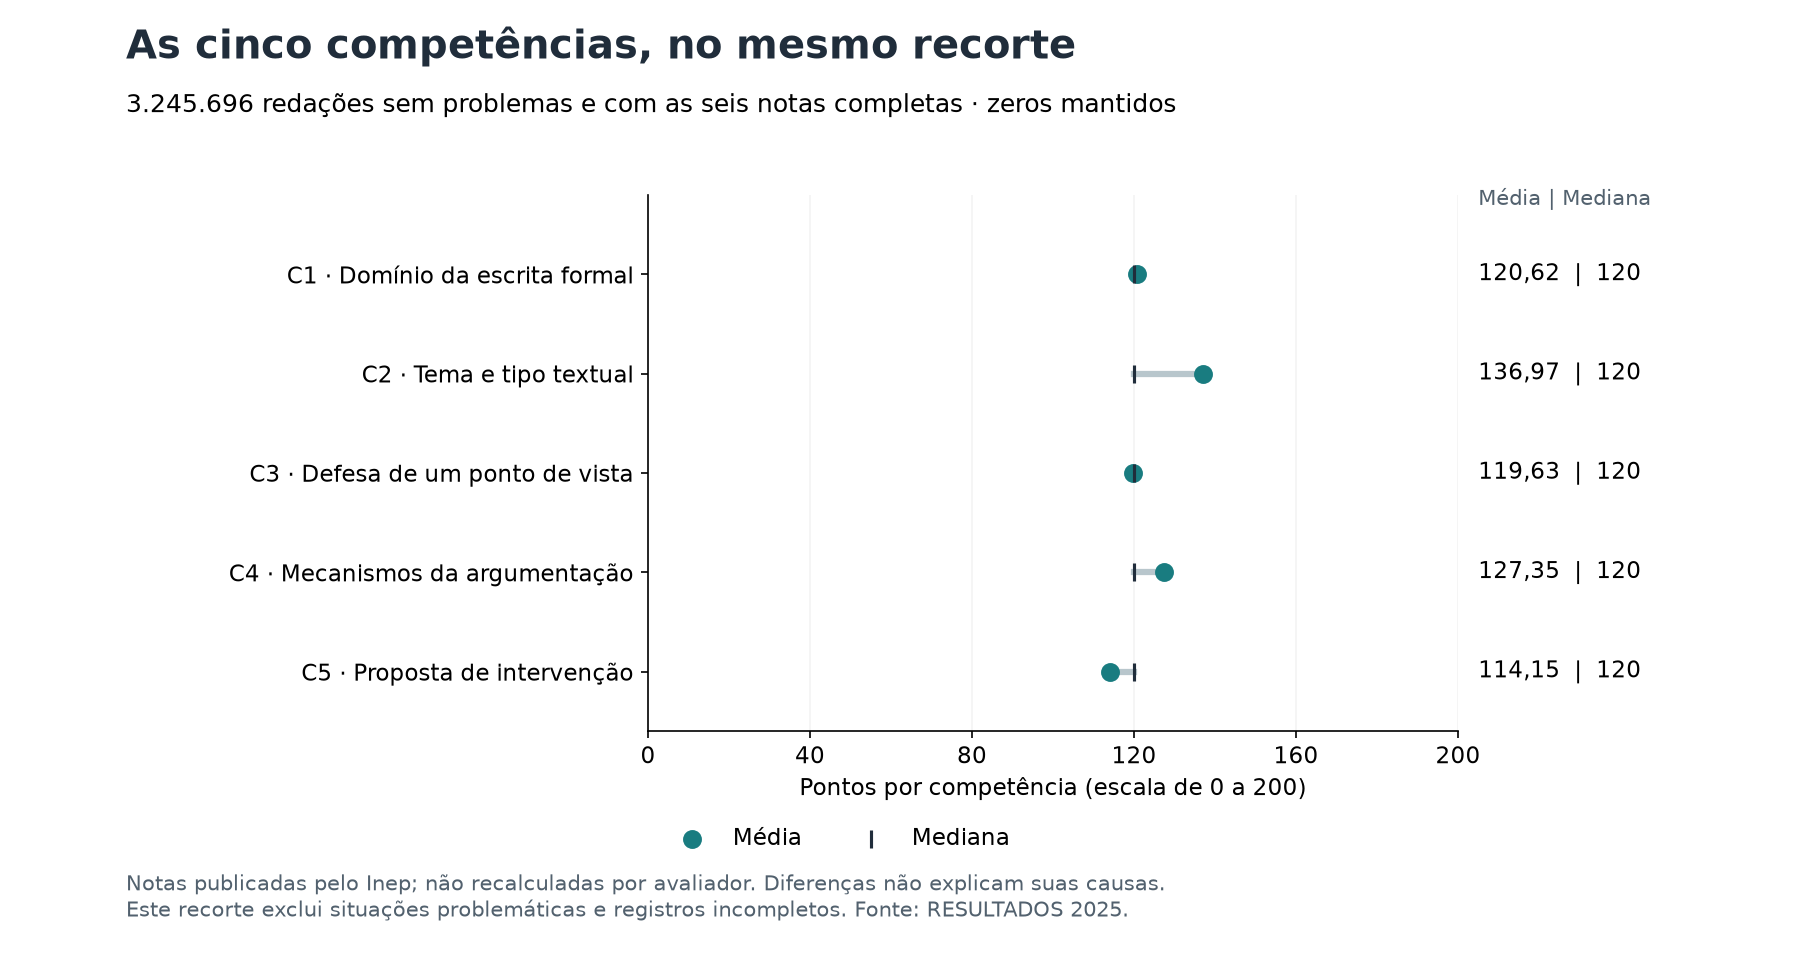

Auditorias e CSVs publicados; trusted preservada.


In [4]:
figuras_redacao = gerar_graficos_redacao(redacao, raiz / "apresentacao/graficos")
for figura in figuras_redacao:
    display(Image(filename=str(figura)))
print("Auditorias e CSVs publicados; trusted preservada.")
